In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc bộ dữ liệu House Prices
df = pd.read_csv("train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [25]:
# 2. Xem số dòng và số cột của dataset
print(f"Kích thước tập dữ liệu (Dòng, Cột): {df.shape}")
df.shape

Kích thước tập dữ liệu (Dòng, Cột): (1460, 81)


(1460, 81)

In [26]:
# 3. Xem trước 5 dòng đầu tiên của tập dữ liệu
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
# 4. Xem thông tin kiểu dữ liệu (Dtype) và dung lượng bộ nhớ
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [28]:
# 5. TỔNG HỢP VÀ PHÂN LOẠI CÁC BIẾN (SUMMARY DATASET)

# Biến định danh và biến mục tiêu
id_col = 'Id'
target_col = 'SalePrice'

# Lấy danh sách các biến định lượng (Numerical) và định tính (Categorical)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Bỏ cột Id và SalePrice ra khỏi danh sách biến đặc trưng
feature_numerical = [c for c in numerical_cols if c not in [id_col, target_col]]

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("="*60)
print("BÁO CÁO TỔNG QUAN TẬP DỮ LIỆU")
print("="*60)
print(f"1. Số dòng: {df.shape[0]} dòng")
print(f"2. Số cột: {df.shape[1]} cột")
print(f"3. Biến mục tiêu (Target): '{target_col}' (Giá bán căn nhà bằng USD)")
print(f"4. Bài toán: Hồi quy (Regression) - Dự đoán giá trị liên tục SalePrice")
print(f"5. Số lượng biến Numerical (Định lượng): {len(feature_numerical)} biến")
print(f"6. Số lượng biến Categorical (Định tính): {len(categorical_cols)} biến")
print(f"7. Biến định danh: '{id_col}'")
print("="*60)

# Bảng tóm tắt số lượng biến theo kiểu dữ liệu
summary_type_df = pd.DataFrame({
    'Nhóm biến': ['Numerical (Định lượng)', 'Categorical (Định tính)', 'Target (Biến mục tiêu)', 'Identifier (Định danh)'],
    'Số lượng': [len(feature_numerical), len(categorical_cols), 1, 1]
})
summary_type_df

BÁO CÁO TỔNG QUAN TẬP DỮ LIỆU
1. Số dòng: 1460 dòng
2. Số cột: 81 cột
3. Biến mục tiêu (Target): 'SalePrice' (Giá bán căn nhà bằng USD)
4. Bài toán: Hồi quy (Regression) - Dự đoán giá trị liên tục SalePrice
5. Số lượng biến Numerical (Định lượng): 36 biến
6. Số lượng biến Categorical (Định tính): 43 biến
7. Biến định danh: 'Id'


,Nhóm biến,Số lượng
0,Numerical (Định lượng),36
1,Categorical (Định tính),43
2,Target (Biến mục tiêu),1
3,Identifier (Định danh),1


In [29]:
# In danh sách chi tiết các biến
print(f"--- DANH SÁCH {len(feature_numerical)} BIẾN NUMERICAL ---")
print(feature_numerical)

print(f"\n--- DANH SÁCH {len(categorical_cols)} BIẾN CATEGORICAL ---")
print(categorical_cols)

--- DANH SÁCH 36 BIẾN NUMERICAL ---
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

--- DANH SÁCH 43 BIẾN CATEGORICAL ---
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functio

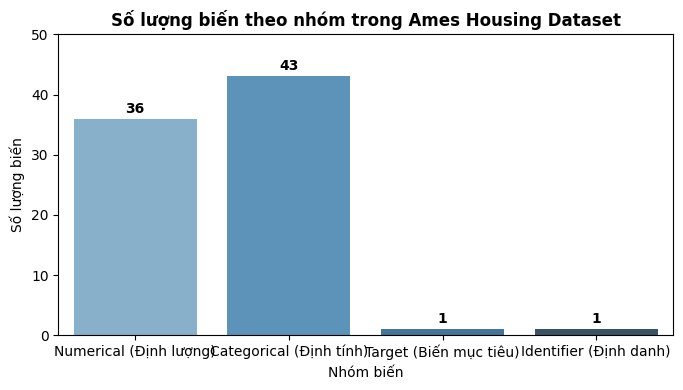

In [30]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x='Nhóm biến', 
    y='Số lượng', 
    data=summary_type_df, 
    hue='Nhóm biến', 
    palette='Blues_d', 
    legend=False
)

plt.title('Số lượng biến theo nhóm trong Ames Housing Dataset', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng biến')
for index, value in enumerate(summary_type_df['Số lượng']):
    plt.text(index, value + 1, str(value), ha='center', fontweight='bold')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

7. PHÂN TÍCH ĐƠN BIẾN - HISTOGRAM & BOXPLOT


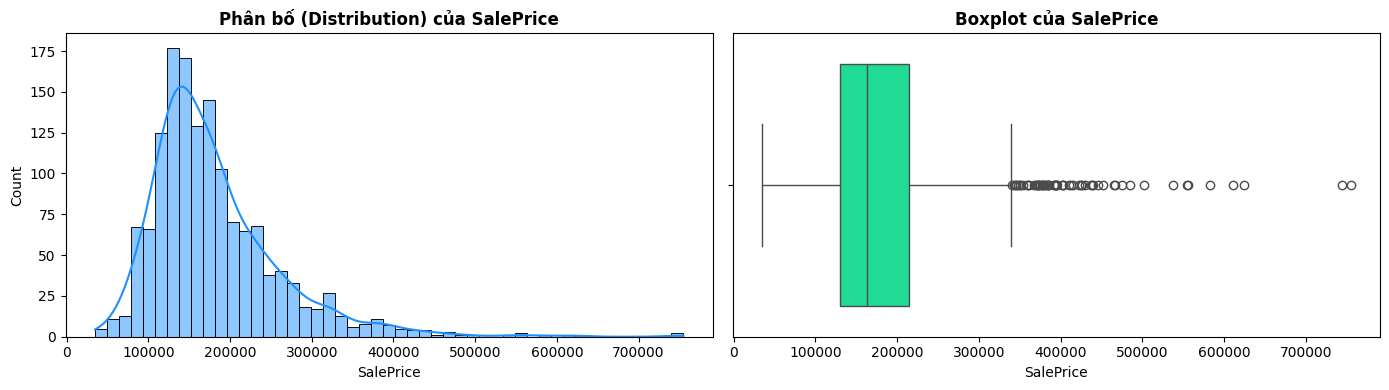

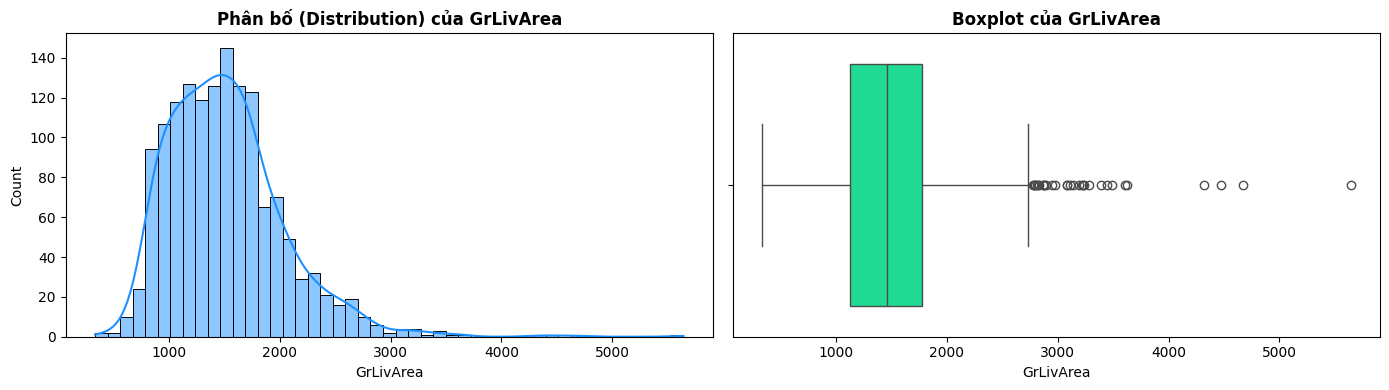

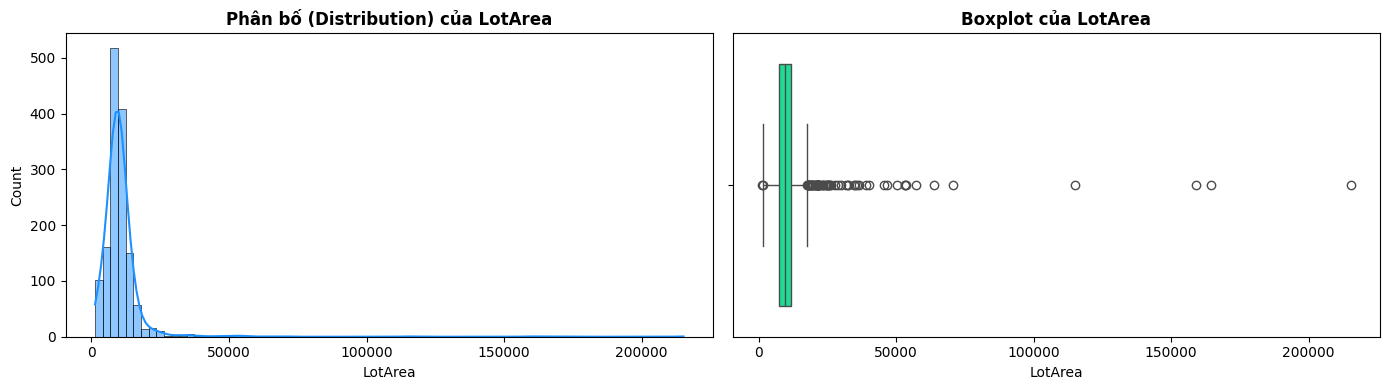

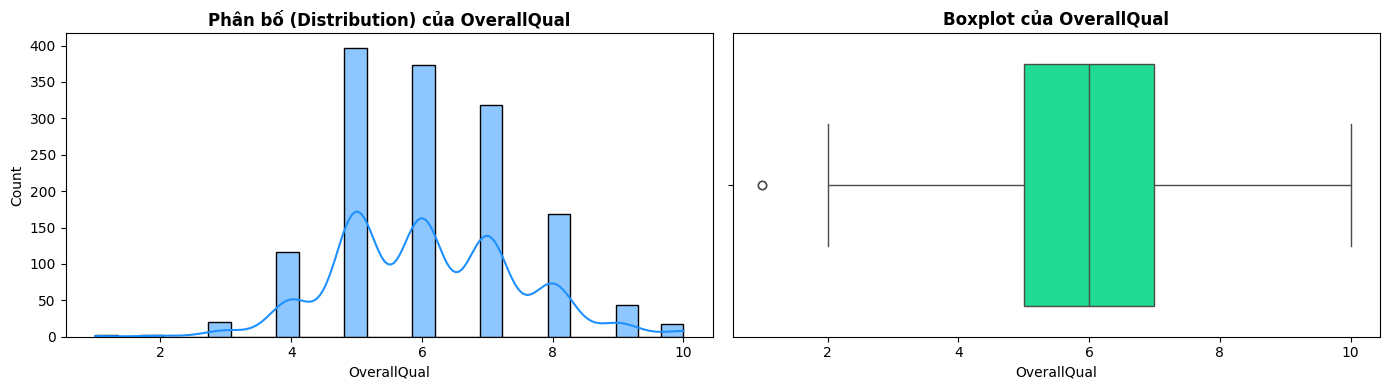

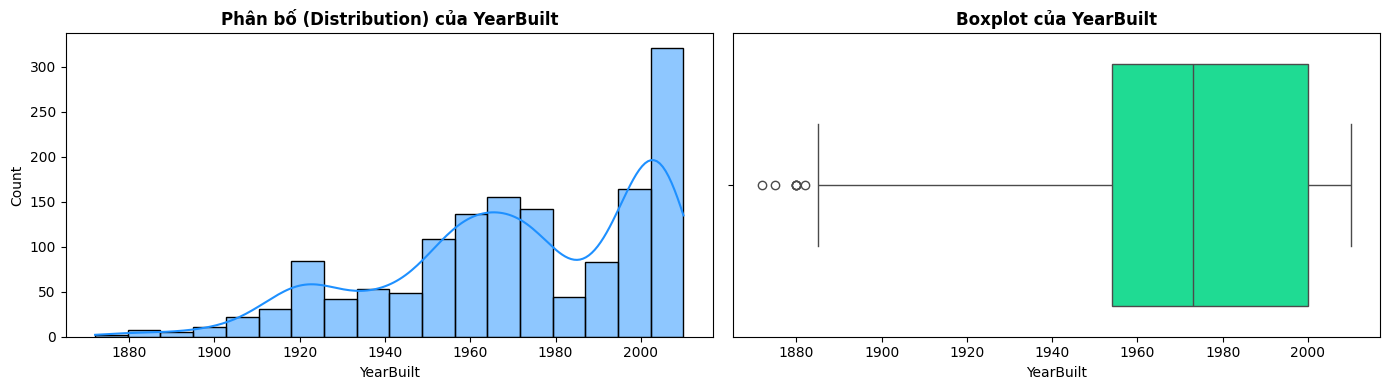

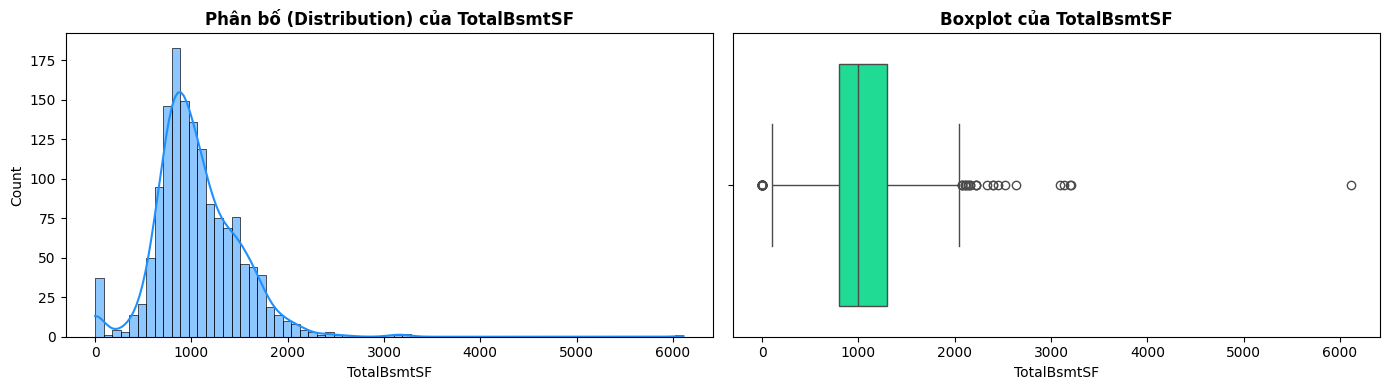

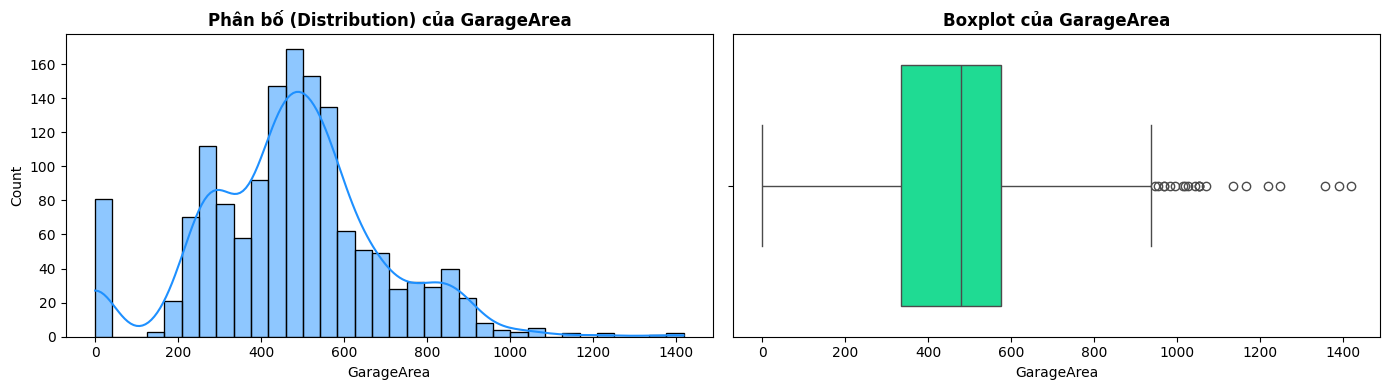

In [ ]:
# 7. PHÂN TÍCH ĐƠN BIẾN DỰA TRÊN CÁC BIẾN QUAN TRỌNG (TV3 YÊU CẦU)
print("="*60)
print("7. PHÂN TÍCH ĐƠN BIẾN - HISTOGRAM & BOXPLOT")
print("="*60)

# Danh sách các biến cần tập trung khảo sát
important_cols = ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 
                  'YearBuilt', 'TotalBsmtSF', 'GarageArea']

for col in important_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Vẽ Histogram xem phân bố và độ lệch
    sns.histplot(df[col], kde=True, ax=axes[0], color='dodgerblue')
    axes[0].set_title(f'Phân bố (Distribution) của {col}', fontweight='bold')
    
    # Vẽ Boxplot xem các giá trị dị thường (outliers)
    sns.boxplot(x=df[col], ax=axes[1], color='mediumspringgreen')
    axes[1].set_title(f'Boxplot của {col}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()